# CTCH (Clinical-Text-guided Bone Disease) Dataset Exploration

This notebook provides a comprehensive exploration of the **CTCH** dataset, which features dual-text reports (X-ray findings and Clinical patient history reports) for multi-label bone disease classification.

## 1. Setup & Imports

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch

# Add parent directory to path to allow importing project modules
sys.path.append(os.path.abspath('..'))

from local_datasets.ctch_dataset import CTCHDataset

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Setup completed successfully!")

Setup completed successfully!


## 2. Load Metadata and Splits

In [2]:
ctch_labels_path = "../data/CTCH/ctch-labels.csv"
ctch_split_path = "../data/CTCH/ctch-split.csv"

if os.path.exists(ctch_labels_path):
    df_ctch = pd.read_csv(ctch_labels_path)
    df_ctch_split = pd.read_csv(ctch_split_path)
    df_ctch_merged = pd.merge(df_ctch_split, df_ctch, on="image_id", how="inner")
    
    print(f"Total merged CTCH samples: {len(df_ctch_merged)}")
    print(f"Columns: {list(df_ctch_merged.columns)}")
    display(df_ctch_merged.head())
else:
    print("CTCH metadata files not found. Make sure the dataset is placed at ../data/CTCH/")

Total merged CTCH samples: 3934
Columns: ['image_id', 'split', 'fracture', 'dislocation', 'bone_tumor', 'infection', 'undetermined', 'upper_limb_fracture', 'lower_limb_fracture', 'spine_fracture', 'other_fracture', 'benign_bone_tumor', 'malignant_bone_tumor']


,image_id,split,fracture,dislocation,bone_tumor,infection,undetermined,upper_limb_fracture,lower_limb_fracture,spine_fracture,other_fracture,benign_bone_tumor,malignant_bone_tumor
0,img-02615-00001.jpg,train,0,0,1,0,0,0,0,0,0,0,1
1,img-06080-00001.jpg,train,0,0,1,0,0,0,0,0,0,1,0
2,img-05368-00001.jpg,train,0,0,1,0,0,0,0,0,0,0,1
3,img-03058-00001.jpg,train,0,0,1,0,0,0,0,0,0,1,0
4,img-02102-00001.jpg,train,0,0,0,0,1,0,0,0,0,0,0


## 3. Pathology Label Distribution (Multi-label)

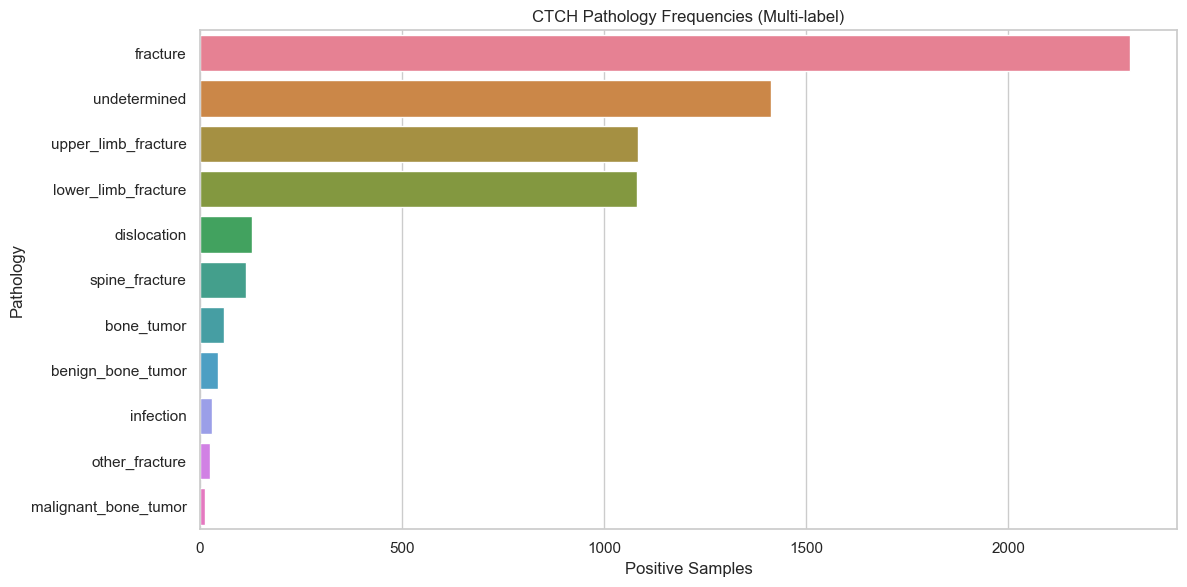

In [3]:
ctch_pathologies = [
    'fracture', 'dislocation', 'bone_tumor', 'infection', 'undetermined',
    'upper_limb_fracture', 'lower_limb_fracture', 'spine_fracture',
    'other_fracture', 'benign_bone_tumor', 'malignant_bone_tumor'
]

if os.path.exists(ctch_labels_path):
    ctch_counts = df_ctch_merged[ctch_pathologies].sum().sort_values(ascending=False)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x=ctch_counts.values, y=ctch_counts.index, hue=ctch_counts.index, legend=False)
    plt.title("CTCH Pathology Frequencies (Multi-label)")
    plt.xlabel("Positive Samples")
    plt.ylabel("Pathology")
    plt.tight_layout()
    plt.show()


## 4. Loading Samples with PyTorch Dataset (Dual Reports)

[Dataset] CTCH 'TRAIN' initialized with 3148 samples.
--- Sample Information ---
Image Type       : <class 'PIL.Image.Image'>
Labels Vector    : tensor([0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])
Active Pathologies: ['undetermined']

[X-Ray Findings Report] (Phase 1 Source):
clinical examination summary: x-ray: fractured left clavicle

[Clinical History Report] (Phase 2 Source):
reason for admission: left shoulder pain
disease history: the patient declared that he was driven to the orthopedic trauma hospital on november 18, 2022
personal medical history: no abnormalities have been detected


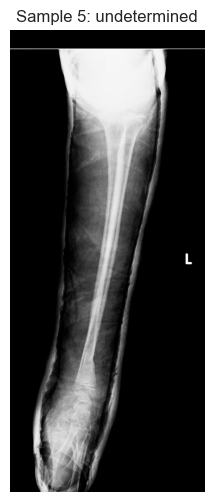

In [4]:
if os.path.exists(ctch_labels_path):
    ctch_dataset = CTCHDataset(
        img_dir="../data/CTCH/images",
        csv_split_path=ctch_split_path,
        csv_labels_path=ctch_labels_path,
        pathologies=ctch_pathologies,
        xray_report_dir="../data/CTCH/reports/xray",
        clinical_report_dir="../data/CTCH/reports/clinical",
        split="train"
    )
    
    # Fetch a sample
    idx = min(5, len(ctch_dataset) - 1)
    img, xray_report, clinical_report, labels = ctch_dataset[idx]
    
    print("--- Sample Information ---")
    print(f"Image Type       : {type(img)}")
    print(f"Labels Vector    : {labels}")
    
    active_labels = [ctch_pathologies[i] for i, val in enumerate(labels) if val == 1.0]
    print(f"Active Pathologies: {active_labels}")
    
    print(f"\n[X-Ray Findings Report] (Phase 1 Source):\n{xray_report}")
    print(f"\n[Clinical History Report] (Phase 2 Source):\n{clinical_report}")
    
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Sample {idx}: {', '.join(active_labels)}")
    plt.axis("off")
    plt.show()